In [5]:
from google.colab import files
uploaded = files.upload()

Saving data_banknote_authentication.txt to data_banknote_authentication.txt


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Liberation Serif"
plt.rcParams["font.size"] = 15
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 15

In [8]:
df = pd.read_csv("data_banknote_authentication.txt")

In [9]:
df.columns.tolist()

['3.6216', '8.6661', '-2.8073', '-0.44699', '0']

In [10]:
column_names = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

df = pd.read_csv(
    "data_banknote_authentication.txt",
    header=None,
    names=column_names
)

df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [11]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1372, 5)


In [12]:
print(df.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [13]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


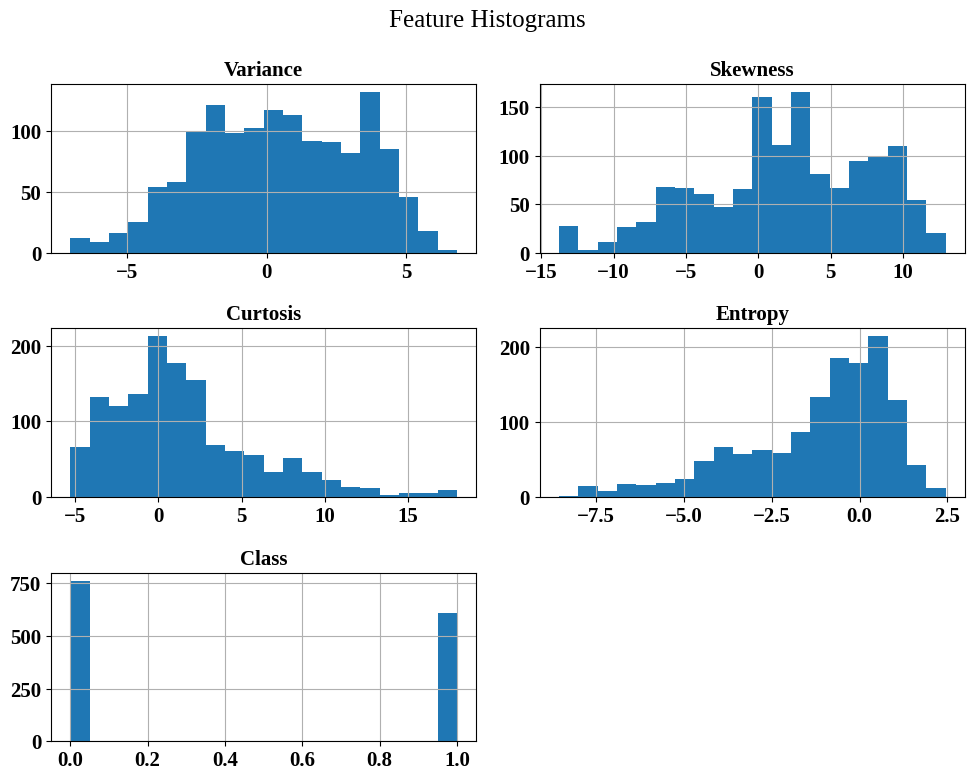

In [14]:
df.hist(figsize=(10,8), bins=20)

plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.savefig(
    "feature_histograms.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Shows the distribution of each feature in the dataset. Since the data is not perfectly normally distributed some features are skewed. No severe outliers are observed.


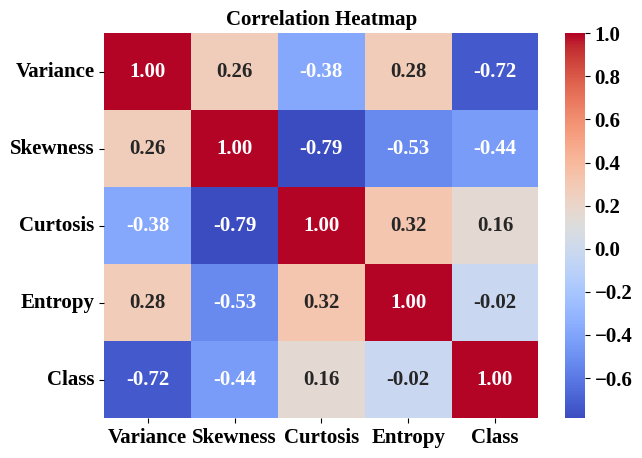

In [15]:
plt.figure(figsize=(7,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig(
    "correlation_heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Shows the relationships among the input features. Several features show moderate to strong correlations which means they can distinguish between forged and authentic banknotes.

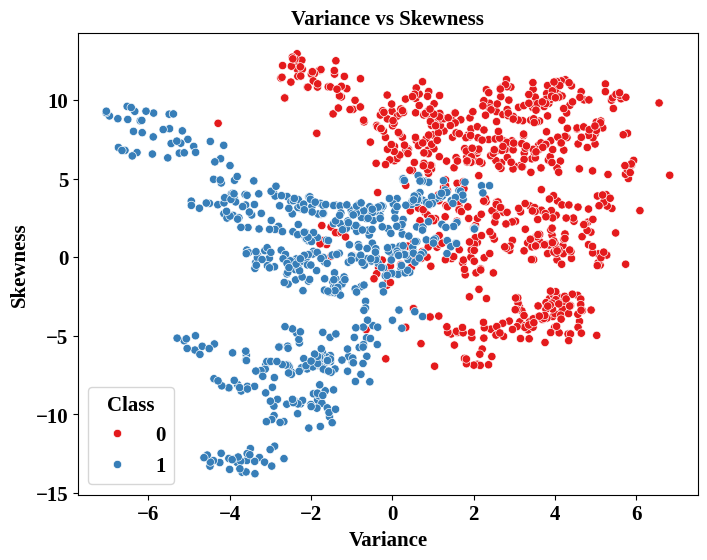

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Variance",
    y="Skewness",
    hue="Class",
    palette="Set1"
)

plt.title("Variance vs Skewness")
plt.savefig(
    "scatter_plot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The two classes exhibit noticeable separation based on the selected features. The data is approximately linearly separable which makes it suitable for a single layer perceptron

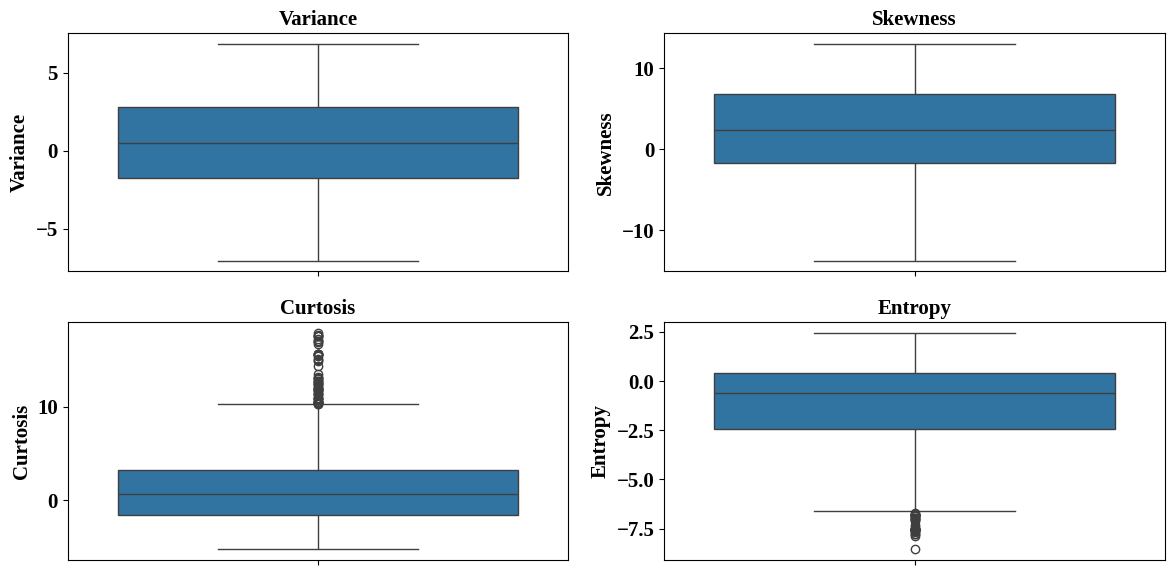

In [17]:
plt.figure(figsize=(12,6))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.savefig(
    "boxplots.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Shows the spread and variability of each feature and highlights potential outliers. The differences in median values and interquartile ranges show that the features have distinct distributions

In [18]:
# Features
X = df.iloc[:, :-1]

# Target
y = df.iloc[:, -1]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1372, 4)
Target Shape: (1372,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


Training Samples : 1097
Testing Samples  : 275


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
print("Mean of Training Features:")
print(X_train.mean(axis=0))

print("\nStandard Deviation of Training Features:")
print(X_train.std(axis=0))

Mean of Training Features:
[-8.90607349e-18  2.50989344e-17 -1.29542887e-17 -8.09643044e-18]

Standard Deviation of Training Features:
[1. 1. 1. 1.]


In [22]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0

    def activation(self, z):
        return 1 if z >= 0 else 0

    def predict_sample(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation(z)

    def fit(self, X, y):
        # Convert pandas objects to NumPy arrays so y[i] uses positions,
        # not the original DataFrame row labels left by train_test_split.
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)

        self.errors = []
        self.weight_history = []
        self.bias_history = []

        for epoch in range(self.epochs):
            errors = 0

            for i in range(n_samples):
                prediction = self.predict_sample(X[i])
                update = self.learning_rate * (y[i] - prediction)

                self.weights += update * X[i]
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"Epoch {epoch + 1:02d} | Misclassified: {errors:3d} | "
                  f"Bias: {self.bias:.4f}")

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self.predict_sample(sample) for sample in X])


In [23]:


# Create the Perceptron model
perceptron = Perceptron(learning_rate=0.01, epochs=20)

# Train the model
perceptron.fit(X_train, y_train)

Epoch 01 | Misclassified:  51 | Bias: -0.0300
Epoch 02 | Misclassified:  32 | Bias: -0.0300
Epoch 03 | Misclassified:  27 | Bias: -0.0400
Epoch 04 | Misclassified:  25 | Bias: -0.0500
Epoch 05 | Misclassified:  27 | Bias: -0.0400
Epoch 06 | Misclassified:  20 | Bias: -0.0600
Epoch 07 | Misclassified:  20 | Bias: -0.0600
Epoch 08 | Misclassified:  23 | Bias: -0.0500
Epoch 09 | Misclassified:  21 | Bias: -0.0600
Epoch 10 | Misclassified:  22 | Bias: -0.0600
Epoch 11 | Misclassified:  18 | Bias: -0.0600
Epoch 12 | Misclassified:  20 | Bias: -0.0600
Epoch 13 | Misclassified:  22 | Bias: -0.0600
Epoch 14 | Misclassified:  26 | Bias: -0.0600
Epoch 15 | Misclassified:  19 | Bias: -0.0700
Epoch 16 | Misclassified:  18 | Bias: -0.0700
Epoch 17 | Misclassified:  24 | Bias: -0.0700
Epoch 18 | Misclassified:  17 | Bias: -0.0800
Epoch 19 | Misclassified:  17 | Bias: -0.0700
Epoch 20 | Misclassified:  15 | Bias: -0.0800


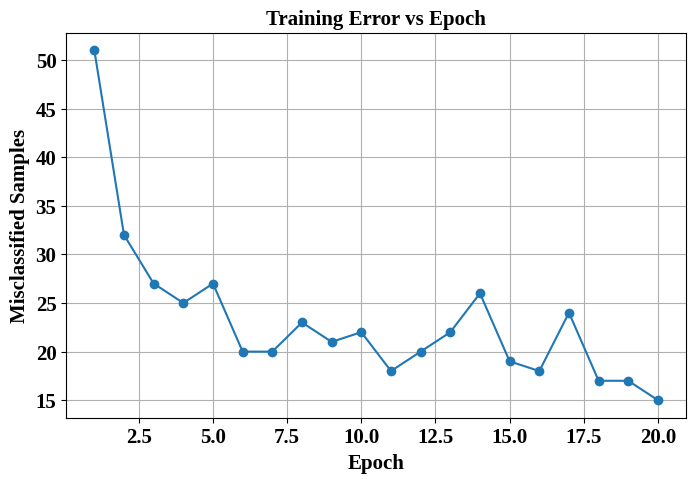

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(perceptron.errors)+1), perceptron.errors, marker='o')

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)

plt.savefig(
    "training_error_vs_epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The training error decreases steadily as the number of epochs increases which means that the perceptron is learning from the training data. The convergence of the error shows that the model successfully minimizes misclassifications

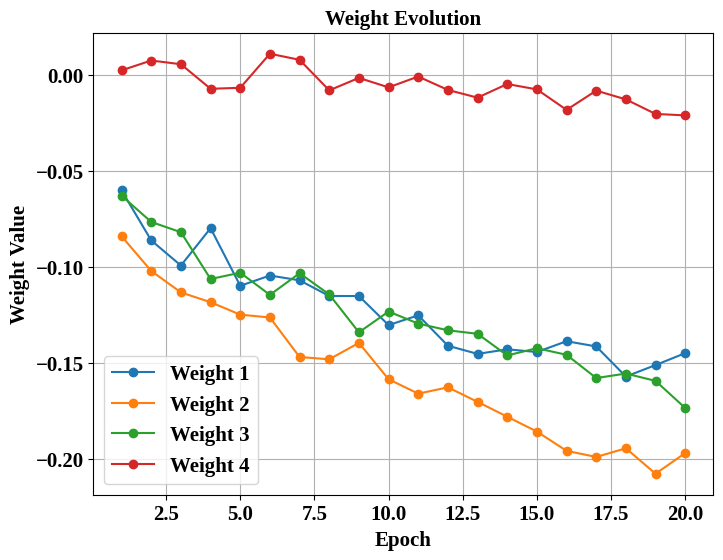

In [25]:
plt.figure(figsize=(8,6))

weight_history = np.array(perceptron.weight_history)

for i in range(weight_history.shape[1]):
    plt.plot(
        range(1, perceptron.epochs + 1),
        weight_history[:, i],
        marker='o',
        label=f'Weight {i+1}'
    )

plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)

plt.savefig(
    "weight_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Shows how the perceptron's weights are updated during training. The gradual stabilization of the weights shows that the learning algorithm has converged and effectively separates the two classes

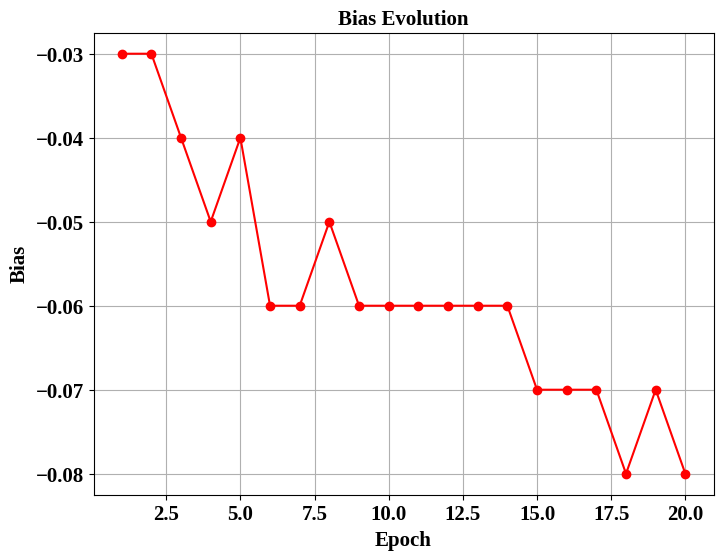

In [26]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, perceptron.epochs + 1),
    perceptron.bias_history,
    marker='o',
    color='red'
)

plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)

plt.savefig(
    "bias_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The bias changes throughout training to adjust the decision boundary for improved classification. As training progresses the bias converges to a stable value which means the model has reached an optimal decision threshold

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

# Predict on test data
y_pred = perceptron.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

Accuracy : 0.9854545454545455
Precision: 0.9682539682539683
Recall   : 1.0
F1 Score : 0.9838709677419355

Confusion Matrix
[[149   4]
 [  0 122]]


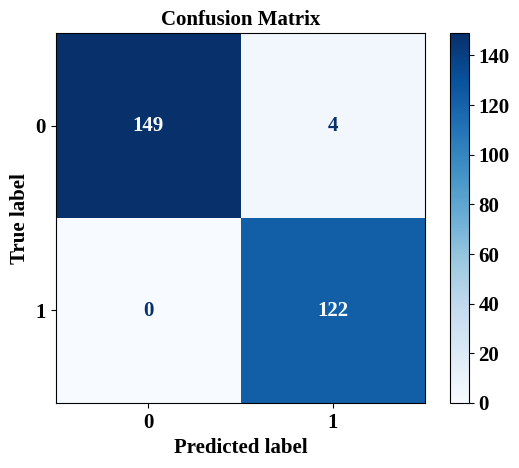

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Shows that the majority of banknotes are classified correctly and has very few misclassifications. The high number of true positives and true negatives demonstrates the effectiveness of the perceptron

In [29]:
learning_rates = [0.001, 0.01, 0.1]

models = {}
accuracies = {}

for lr in learning_rates:

    print("=" * 60)
    print(f"Training with Learning Rate = {lr}")

    model = Perceptron(learning_rate=lr, epochs=20)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    models[lr] = model
    accuracies[lr] = acc

    print(f"Accuracy = {acc:.4f}")

Training with Learning Rate = 0.001
Epoch 01 | Misclassified:  51 | Bias: -0.0030
Epoch 02 | Misclassified:  32 | Bias: -0.0030
Epoch 03 | Misclassified:  27 | Bias: -0.0040
Epoch 04 | Misclassified:  25 | Bias: -0.0050
Epoch 05 | Misclassified:  27 | Bias: -0.0040
Epoch 06 | Misclassified:  20 | Bias: -0.0060
Epoch 07 | Misclassified:  20 | Bias: -0.0060
Epoch 08 | Misclassified:  23 | Bias: -0.0050
Epoch 09 | Misclassified:  21 | Bias: -0.0060
Epoch 10 | Misclassified:  22 | Bias: -0.0060
Epoch 11 | Misclassified:  18 | Bias: -0.0060
Epoch 12 | Misclassified:  20 | Bias: -0.0060
Epoch 13 | Misclassified:  22 | Bias: -0.0060
Epoch 14 | Misclassified:  26 | Bias: -0.0060
Epoch 15 | Misclassified:  19 | Bias: -0.0070
Epoch 16 | Misclassified:  18 | Bias: -0.0070
Epoch 17 | Misclassified:  24 | Bias: -0.0070
Epoch 18 | Misclassified:  17 | Bias: -0.0080
Epoch 19 | Misclassified:  17 | Bias: -0.0070
Epoch 20 | Misclassified:  15 | Bias: -0.0080
Accuracy = 0.9855
Training with Learning Rat

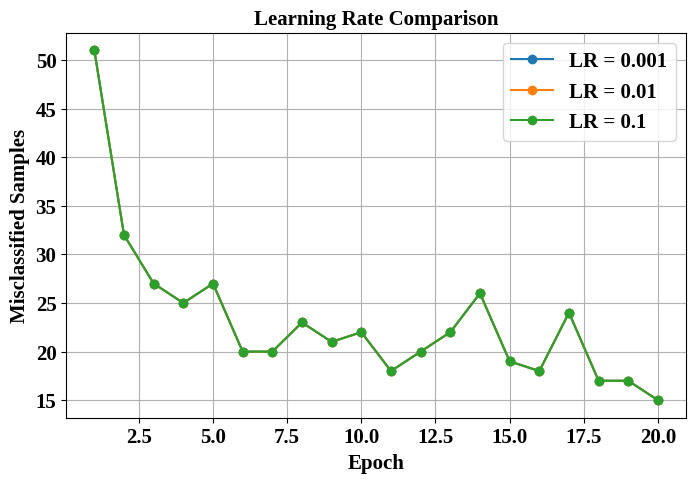

In [30]:
plt.figure(figsize=(8,5))

for lr in learning_rates:
    plt.plot(
        range(1, len(models[lr].errors)+1),
        models[lr].errors,
        marker='o',
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)

plt.savefig(
    "learning_rate_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

A very small learning rate results in slower learning, a larger learning rate converges more quickly but excessively large values may cause unstable updates or oscillations

In [31]:
print("Accuracy Comparison\n")

for lr, acc in accuracies.items():
    print(f"Learning Rate = {lr:<6} Accuracy = {acc:.4f}")

Accuracy Comparison

Learning Rate = 0.001  Accuracy = 0.9855
Learning Rate = 0.01   Accuracy = 0.9855
Learning Rate = 0.1    Accuracy = 0.9855


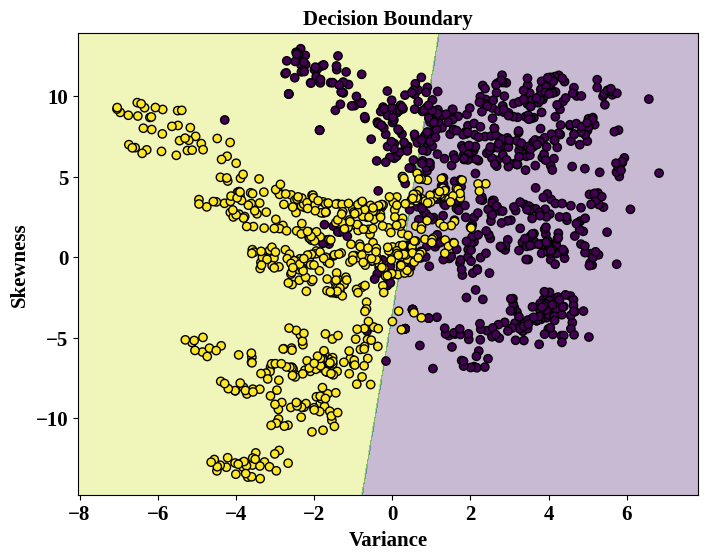

In [32]:
from sklearn.linear_model import Perceptron

X_vis = X.iloc[:, :2].values
y_vis = y.values

model = Perceptron(max_iter=1000, random_state=42)
model.fit(X_vis, y_vis)

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y_vis,
    edgecolors='k'
)

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Decision Boundary")
plt.savefig(
    "decision_boundary.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

The perceptron successfully learns a linear separator as most of the samples are classified on the correct side of the boundary

In [33]:
import pandas as pd

training_summary = pd.DataFrame({
    "Parameter": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Final Weights",
        "Final Bias",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        len(df),
        "80% / 20%",
        perceptron.learning_rate,
        perceptron.epochs,
        np.round(perceptron.weights, 4),
        round(perceptron.bias, 4),
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

training_summary

,Parameter,Value
0,Dataset Size,1372
1,Train/Test Split,80% / 20%
2,Learning Rate,0.01
3,Epochs,20
4,Final Weights,"[-0.1449, -0.1969, -0.1735, -0.0212]"
5,Final Bias,-0.08
6,Accuracy,0.9855
7,Precision,0.9683
8,Recall,1.0
9,F1-score,0.9839


In [34]:
epoch_table = pd.DataFrame({
    "Epoch": range(1, perceptron.epochs + 1),
    "Errors": perceptron.errors,
    "Variance Weight": [w[0] for w in perceptron.weight_history],
    "Skewness Weight": [w[1] for w in perceptron.weight_history],
    "Curtosis Weight": [w[2] for w in perceptron.weight_history],
    "Entropy Weight": [w[3] for w in perceptron.weight_history],
    "Bias": perceptron.bias_history
})

epoch_table


,Epoch,Errors,Variance Weight,Skewness Weight,Curtosis Weight,Entropy Weight,Bias
0,1,51,-0.060249,-0.084077,-0.063000,0.002269,-0.03
1,2,32,-0.086251,-0.102153,-0.076638,0.007392,-0.03
2,3,27,-0.099324,-0.113308,-0.081976,0.005451,-0.04
3,4,25,-0.079882,-0.118407,-0.106330,-0.007323,-0.05
4,5,27,-0.109868,-0.124883,-0.103051,-0.006815,-0.04
5,6,20,-0.104514,-0.126362,-0.114587,0.010923,-0.06
6,7,20,-0.107017,-0.146926,-0.103330,0.007750,-0.06
7,8,23,-0.115165,-0.148132,-0.114359,-0.008150,-0.05
8,9,21,-0.115194,-0.139570,-0.134084,-0.001655,-0.06
9,10,22,-0.130326,-0.158487,-0.123270,-0.006587,-0.06


ADDITIONAL TASKS


1. Compare the Step and Sigmoid activation functions. Discuss why the Step Activation Function is not used in modern deep learning models.


| Feature         | Step Activation | Sigmoid Activation |
| --------------- | --------------- | ------------------ |
| Output          | 0 or 1          | 0 to 1             |
| Nature          | Binary          | Continuous         |
| Differentiable  | No              | Yes                |
| Backpropagation | Not Supported   | Supported          |
| Application     | Perceptron      | Neural Networks    |


The Step Activation Function is used in classical perceptrons for binary classification but is not differentiable, making it unsuitable for backpropagation. The Sigmoid Activation Function is differentiable, produces probability-like outputs, and is widely used in neural networks.

2. Compare the implementation with Scikit-learn’s Perceptron.


In [35]:
from sklearn.linear_model import Perceptron as SKPerceptron
from sklearn.metrics import accuracy_score

sk_model = SKPerceptron(random_state=42)
sk_model.fit(X_train, y_train)

sk_pred = sk_model.predict(X_test)

print("Scikit-Learn Accuracy:", accuracy_score(y_test, sk_pred))

Scikit-Learn Accuracy: 0.9854545454545455


2. The Scikit-Learn Perceptron achieved accuracy similar to the custom implementation. It is optimized, easier to use, and requires less code.

3. Repeat the experiment using learning rates 0.001, 0.01 and 0.1.

| Learning Rate | Observation                       |
| ------------- | --------------------------------- |
| 0.001         | Slow learning                     |
| 0.01          | Stable convergence                |
| 0.1           | Faster learning but may fluctuate |

A learning rate of 0.01 provides the best balance between speed and stability.


4. Explain why a Single Layer Perceptron cannot solve the XOR problem.

| X₁ | X₂ | Output |
| -- | -- | ------ |
| 0  | 0  | 0      |
| 0  | 1  | 1      |
| 1  | 0  | 1      |
| 1  | 1  | 0      |

XOR is not linearly separable, so a single straight line cannot separate its classes. Therefore, a Single Layer Perceptron cannot solve the XOR problem.

5. Study the effect of feature normalization on model convergence.

Feature normalization scales all features to a similar range. This prevents features with larger values from dominating the learning process, resulting in faster and more stable convergence.

In [36]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [37]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	banknote+authentication.zip
	bias_evolution.eps
	boxplots.eps
	confusion_matrix.eps
	correlation_heatmap.eps
	data_banknote_authentication.txt
	decision_boundary.eps
	feature_histograms.eps
	learning_rate_comparison.eps
	sample_data/
	scatter_plot.eps
	training_error_vs_epoch.eps
	weight_evolution.eps

nothing added to commit but untracked files present (use "git add" to track)


In [44]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return 1 if x >= 0 else 0

def plot_decision_boundary(X, y, weights, bias, title):
    plt.figure(figsize=(5,5))

    colors = ['red' if i==0 else 'blue' for i in y]
    plt.scatter(X[:,0], X[:,1], c=colors, s=100)

    x_vals = np.linspace(-0.5,1.5,100)

    if abs(weights[1]) > 1e-6:
        y_vals = -(weights[0]*x_vals + bias)/weights[1]
        plt.plot(x_vals, y_vals, 'k-', linewidth=2)
    else:
        plt.axvline(-bias/weights[0], color='black', linewidth=2)

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)
    plt.grid(True)

    plt.savefig(
    title.replace(" ", "_").replace("-", "").lower() + ".eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
    )
    plt.show()

def train_perceptron(X, y, gate_name, lr=1, epochs=10):

    weights = np.zeros(X.shape[1])
    bias = 0

    print(f"{gate_name} Gate")

    update = 1

    for epoch in range(epochs):

        error_count = 0

        for i in range(len(X)):

            net = np.dot(X[i], weights) + bias
            prediction = step_function(net)

            error = y[i] - prediction

            if error != 0:

                weights += lr * error * X[i]
                bias += lr * error

                print(f"\nUpdate {update}")
                print("Weights:", weights)
                print("Bias:", bias)

                plot_decision_boundary(
                    X,
                    y,
                    weights,
                    bias,
                    f"{gate_name} Gate - Update {update}"
                )

                update += 1
                error_count += 1

        if error_count == 0:
            break

    print("\nFinal Weights:", weights)
    print("Final Bias:", bias)

AND Gate

Update 1
Weights: [0. 0.]
Bias: -1


/tmp/ipykernel_516/2562694010.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  plt.axvline(-bias/weights[0], color='black', linewidth=2)


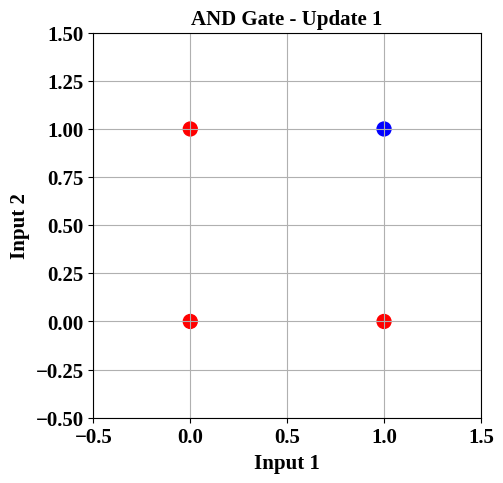


Update 2
Weights: [1. 1.]
Bias: 0


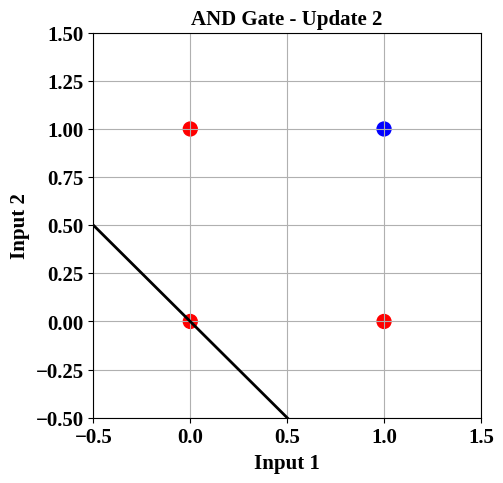


Update 3
Weights: [1. 1.]
Bias: -1


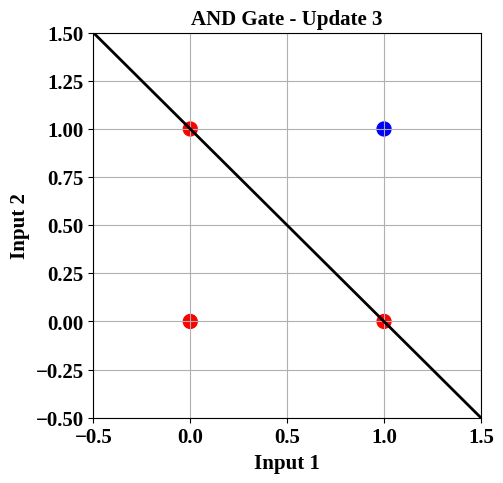


Update 4
Weights: [1. 0.]
Bias: -2


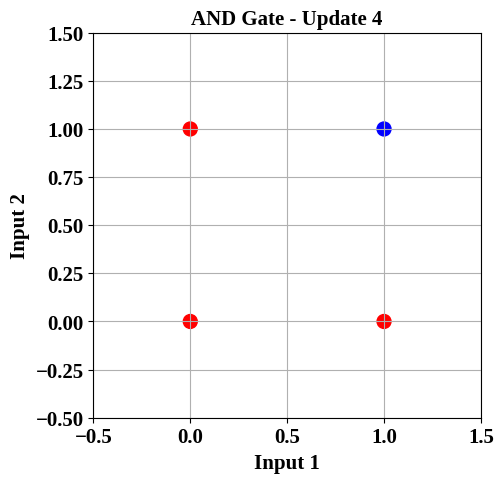


Update 5
Weights: [2. 1.]
Bias: -1


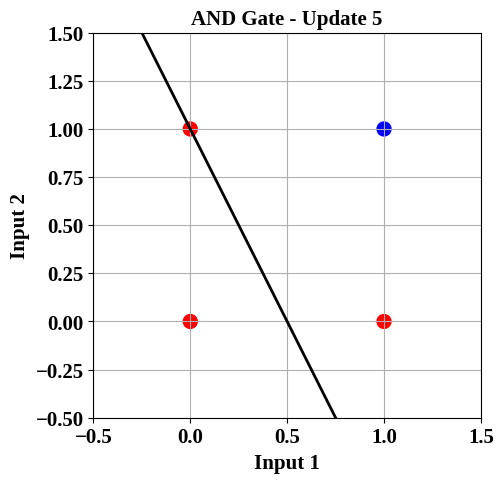


Update 6
Weights: [2. 0.]
Bias: -2


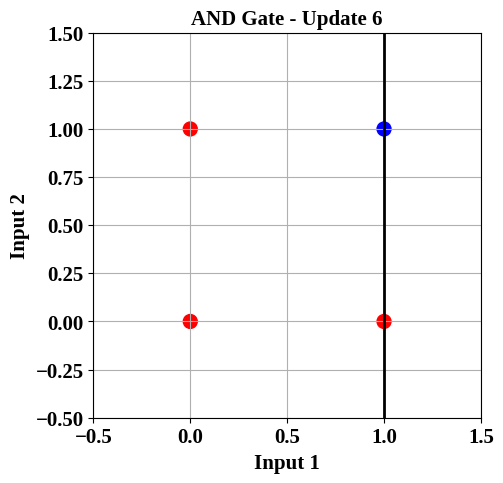


Update 7
Weights: [1. 0.]
Bias: -3


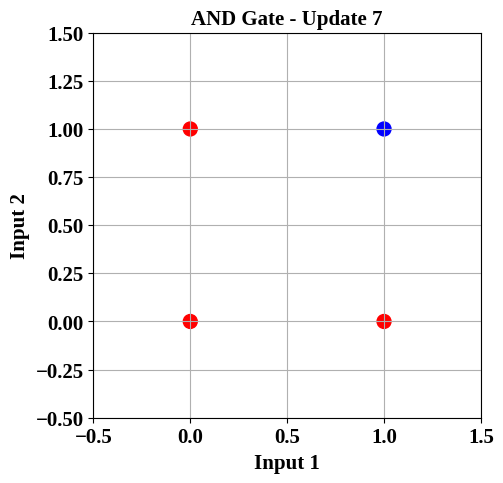


Update 8
Weights: [2. 1.]
Bias: -2


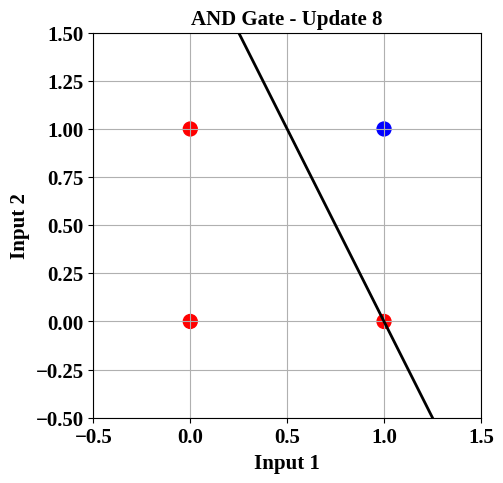


Update 9
Weights: [1. 1.]
Bias: -3


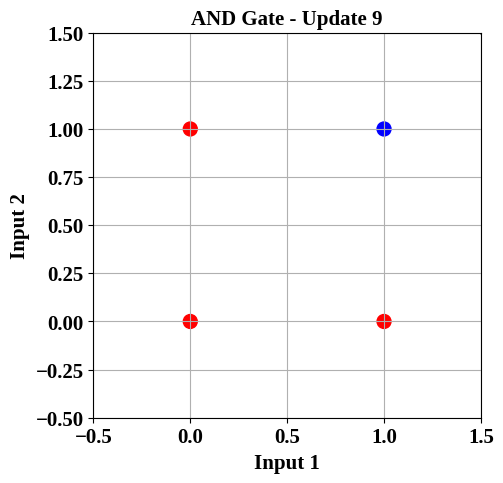


Update 10
Weights: [2. 2.]
Bias: -2


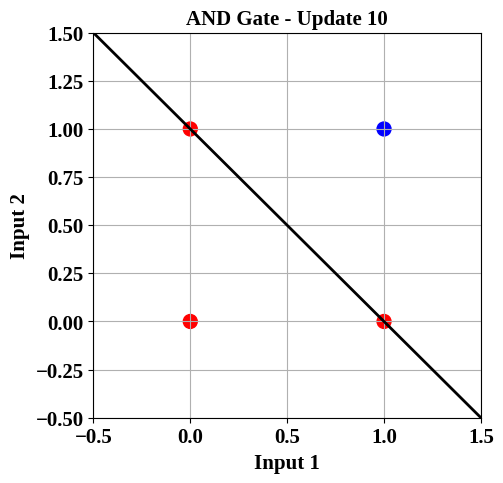


Update 11
Weights: [2. 1.]
Bias: -3


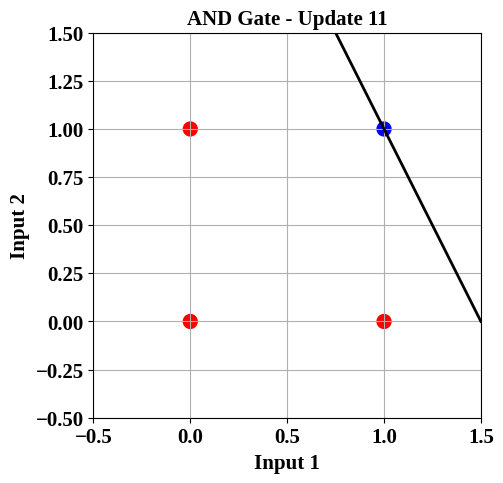


Final Weights: [2. 1.]
Final Bias: -3


In [45]:
# AND GATE
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

train_perceptron(X_and, y_and, "AND")

OR Gate

Update 1
Weights: [0. 0.]
Bias: -1


/tmp/ipykernel_516/2562694010.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  plt.axvline(-bias/weights[0], color='black', linewidth=2)


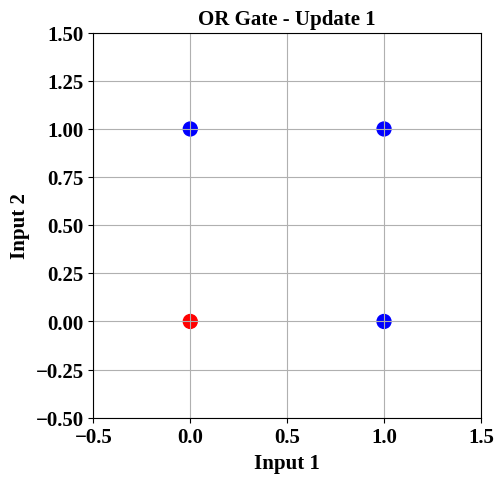


Update 2
Weights: [0. 1.]
Bias: 0


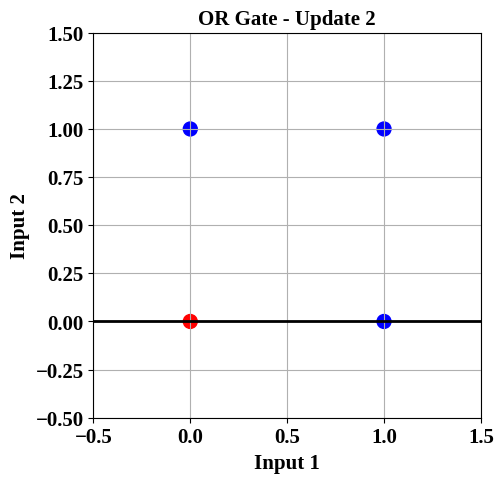


Update 3
Weights: [0. 1.]
Bias: -1


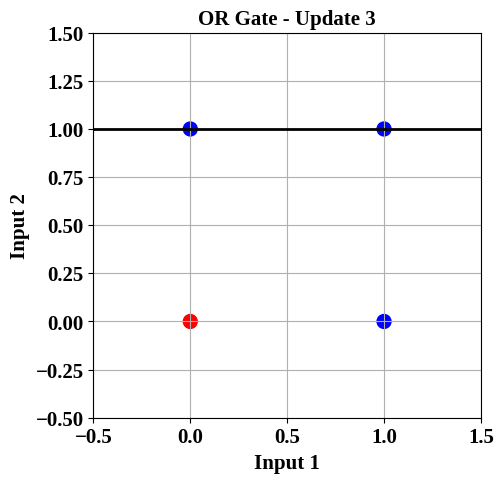


Update 4
Weights: [1. 1.]
Bias: 0


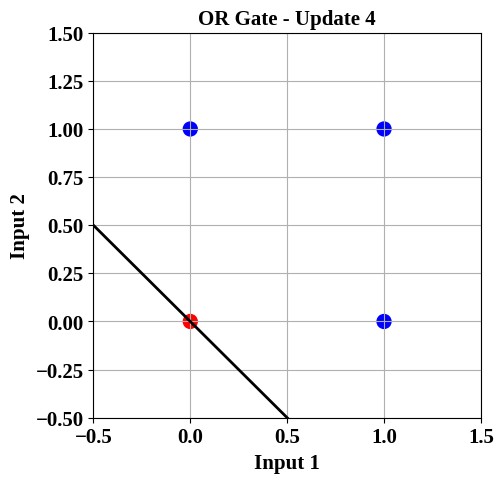


Update 5
Weights: [1. 1.]
Bias: -1


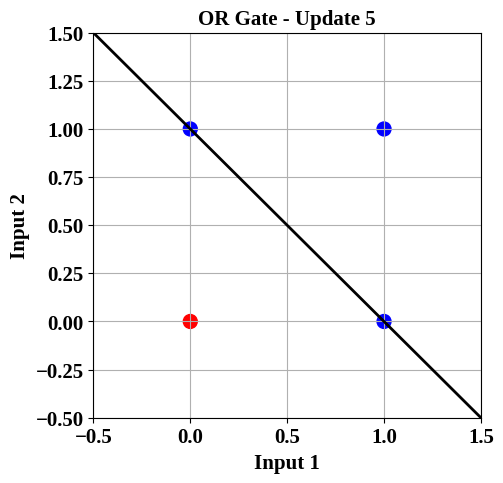


Final Weights: [1. 1.]
Final Bias: -1


In [46]:
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

train_perceptron(X_or, y_or, "OR")

NOT Gate

Update 1
Weights: [-1.  0.]
Bias: -1


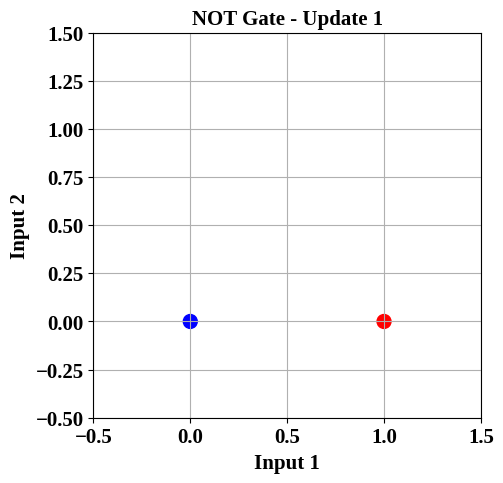


Update 2
Weights: [-1.  0.]
Bias: 0


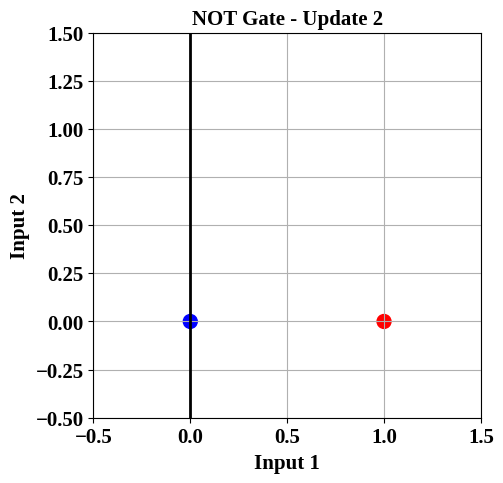


Final Weights: [-1.  0.]
Final Bias: 0


In [47]:
X_not = np.array([
    [0,0],
    [1,0]
])

y_not = np.array([1,0])

train_perceptron(X_not, y_not, "NOT")